In [30]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

In [31]:
#loading DB credentials
load_dotenv()

#connecting to DB using SQL Alchemy
def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
        f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
    )

In [32]:
#pulling data from DB
def load_data() -> pd.DataFrame:
    query = """
        SELECT
            u.user_id,
            u.age,
            u.country,
            u.signup_date,
            s.plan,
            s.billing_cycle,
            s.monthly_price,
            s.yearly_price,
            s.cancelled,
            s.cancellation_date,
            s.last_renewal_date,
            s.next_renewal_date,
            s.start_date,
            e.avg_watch_hours_per_week,
            e.number_of_logins_per_week,
            e.days_since_last_watch,
            e.completion_rate,
            st.tickets_last_30d,
            b.price_increase_last_6m,
            b.payment_failures,
            cl.churn_type
        FROM users u
        JOIN subscriptions s ON u.user_id = s.user_id
        JOIN engagement e ON u.user_id = e.user_id
        JOIN support_tickets st ON u.user_id = st.user_id
        JOIN billing b ON u.user_id = b.user_id
        JOIN churn_labels cl ON u.user_id = cl.user_id
    """

    with get_engine().connect() as connection:
        df = pd.read_sql(query, connection)

    return df


In [33]:
#loading data as a dataframe
df = load_data()
print(df.shape)

(10000, 21)


In [34]:
#checking data types - we can see that date fields are as object
df.dtypes

user_id                        int64
age                            int64
country                       object
signup_date                   object
plan                          object
billing_cycle                 object
monthly_price                float64
yearly_price                 float64
cancelled                       bool
cancellation_date             object
last_renewal_date             object
next_renewal_date             object
start_date                    object
avg_watch_hours_per_week     float64
number_of_logins_per_week      int64
days_since_last_watch          int64
completion_rate              float64
tickets_last_30d               int64
price_increase_last_6m          bool
payment_failures               int64
churn_type                     int64
dtype: object

In [35]:
#Changing dtype for the dates
date_cols = ['signup_date', 'start_date', 'cancellation_date', 'last_renewal_date', 'next_renewal_date']
df[date_cols] = df[date_cols].apply(pd.to_datetime)

In [36]:
#re-checking data types - to see if date fields were updated to the correct type
df.dtypes

user_id                               int64
age                                   int64
country                              object
signup_date                  datetime64[ns]
plan                                 object
billing_cycle                        object
monthly_price                       float64
yearly_price                        float64
cancelled                              bool
cancellation_date            datetime64[ns]
last_renewal_date            datetime64[ns]
next_renewal_date            datetime64[ns]
start_date                   datetime64[ns]
avg_watch_hours_per_week            float64
number_of_logins_per_week             int64
days_since_last_watch                 int64
completion_rate                     float64
tickets_last_30d                      int64
price_increase_last_6m                 bool
payment_failures                      int64
churn_type                            int64
dtype: object

In [37]:
df.describe()

,user_id,age,signup_date,monthly_price,yearly_price,cancellation_date,last_renewal_date,next_renewal_date,start_date,avg_watch_hours_per_week,number_of_logins_per_week,days_since_last_watch,completion_rate,tickets_last_30d,payment_failures,churn_type
count,10000.00000,10000.000000,10000,10000.000000,5054.000000,1504,10000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,41.814600,2024-02-18 01:31:26.400000,14.889000,160.821539,2026-01-15 19:39:34.468084992,2025-11-28 15:51:50.400000,2026-06-15 23:16:48,2024-02-18 01:31:26.400000,10.062772,10.079500,30.075700,0.601523,2.497300,1.003900,0.428400
min,1.00000,18.000000,2022-01-26 00:00:00,9.990000,107.890000,2025-03-27 00:00:00,2025-03-07 00:00:00,2026-03-07 00:00:00,2022-01-26 00:00:00,0.010000,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000
25%,2500.75000,30.000000,2023-02-02 00:00:00,9.990000,107.890000,2025-12-27 00:00:00,2025-09-08 00:00:00,2026-03-21 00:00:00,2023-02-02 00:00:00,4.980000,5.000000,15.000000,0.400000,1.000000,0.000000,0.000000
50%,5000.50000,42.000000,2024-02-21 00:00:00,14.990000,161.890000,2026-02-20 00:00:00,2026-02-07 00:00:00,2026-04-03 00:00:00,2024-02-21 00:00:00,10.130000,10.000000,30.000000,0.600000,2.000000,1.000000,0.000000
75%,7500.25000,54.000000,2025-03-05 00:00:00,19.990000,215.890000,2026-03-02 00:00:00,2026-02-21 00:00:00,2026-09-12 00:00:00,2025-03-05 00:00:00,15.060000,15.000000,45.000000,0.800000,4.000000,2.000000,0.000000
max,10000.00000,65.000000,2026-03-06 00:00:00,19.990000,215.890000,2026-03-06 00:00:00,2026-03-06 00:00:00,2027-03-06 00:00:00,2026-03-06 00:00:00,20.000000,20.000000,60.000000,1.000000,5.000000,2.000000,2.000000
std,2886.89568,13.827861,NaN,4.107491,44.529420,NaN,NaN,NaN,NaN,5.796687,6.128176,17.626612,0.230836,1.713034,0.818994,0.797582


In [38]:
#it si expected to see nulls in yearly price and cancellation dates, because if the client chooses the monthly subscription - yearly will be null, the same for cancellation date - if they didn't cancel it it should be null
df.isnull().sum()

user_id                         0
age                             0
country                         0
signup_date                     0
plan                            0
billing_cycle                   0
monthly_price                   0
yearly_price                 4946
cancelled                       0
cancellation_date            8496
last_renewal_date               0
next_renewal_date               0
start_date                      0
avg_watch_hours_per_week        0
number_of_logins_per_week       0
days_since_last_watch           0
completion_rate                 0
tickets_last_30d                0
price_increase_last_6m          0
payment_failures                0
churn_type                      0
dtype: int64

In [39]:
df.head()

,user_id,age,country,signup_date,plan,billing_cycle,monthly_price,yearly_price,cancelled,cancellation_date,...,next_renewal_date,start_date,avg_watch_hours_per_week,number_of_logins_per_week,days_since_last_watch,completion_rate,tickets_last_30d,price_increase_last_6m,payment_failures,churn_type
0,1,55,Portugal,2026-02-08,Basic,monthly,9.99,NaN,False,NaT,...,2026-03-10,2026-02-08,12.43,19,50,0.24,4,False,2,2
1,2,50,Brazil,2024-05-03,Standard,yearly,14.99,161.89,True,2025-07-17,...,2026-05-03,2024-05-03,7.06,4,45,0.22,5,False,0,1
2,3,21,Argentina,2025-10-27,Premium,yearly,19.99,215.89,False,NaT,...,2026-10-27,2025-10-27,15.38,17,44,0.54,1,False,1,2
3,4,24,Argentina,2025-04-01,Standard,yearly,14.99,161.89,False,NaT,...,2026-04-01,2025-04-01,9.08,11,58,0.35,0,True,2,0
4,5,21,South Korea,2025-02-08,Standard,yearly,14.99,161.89,False,NaT,...,2027-02-08,2025-02-08,5.01,18,34,0.57,1,True,0,0


Churn distribution

In [40]:
#checking if churn distribution is balanced
churn_count = df['churn_type'].value_counts()
pct = df["churn_type"].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({"count": churn_count, "%": pct}))

            count     %
churn_type             
0            7672  76.7
2            1956  19.6
1             372   3.7


In [41]:
#defining categorical, continuos and target group fields
CONTINUOUS_COLS = [
    "age",
    "avg_watch_hours_per_week",
    "number_of_logins_per_week",
    "days_since_last_watch",
    "completion_rate",
    "monthly_price",
    "yearly_price",
    "payment_failures"
]

CATEGORICAL_COLS = [
    "country",
    "plan",
    "billing_cycle",
    "price_increase_last_6m"
]

TARGET_COLS = [
    "cancelled",
    "churn_type"
]


In [42]:
sns.set_theme(style="darkgrid")

Single variable analysis

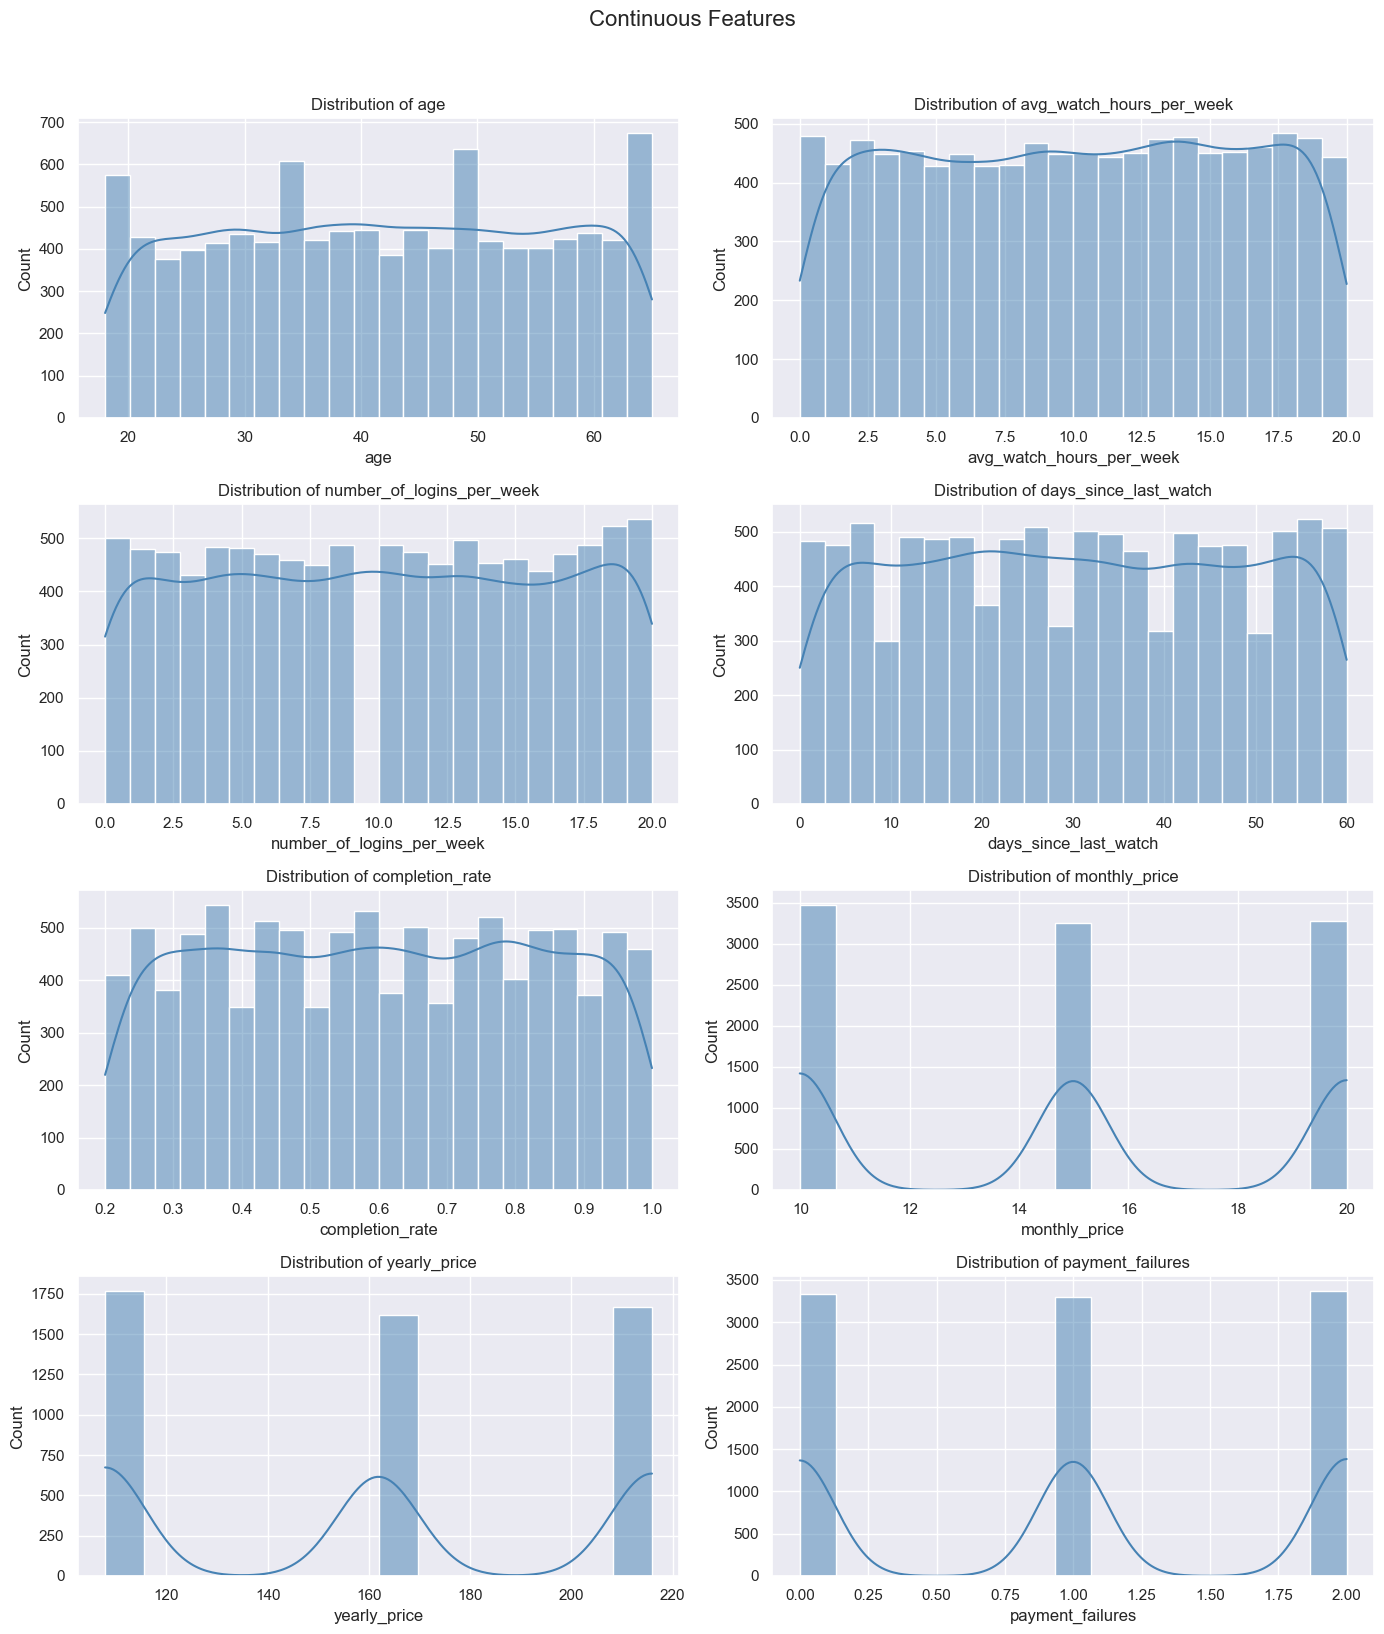

In [43]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS_COLS):
    sns.histplot(df[col], ax=axes[i], kde=True, color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.suptitle("Continuous Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("graphs/single_variable_continuous.png", dpi=150, bbox_inches="tight")
plt.show()

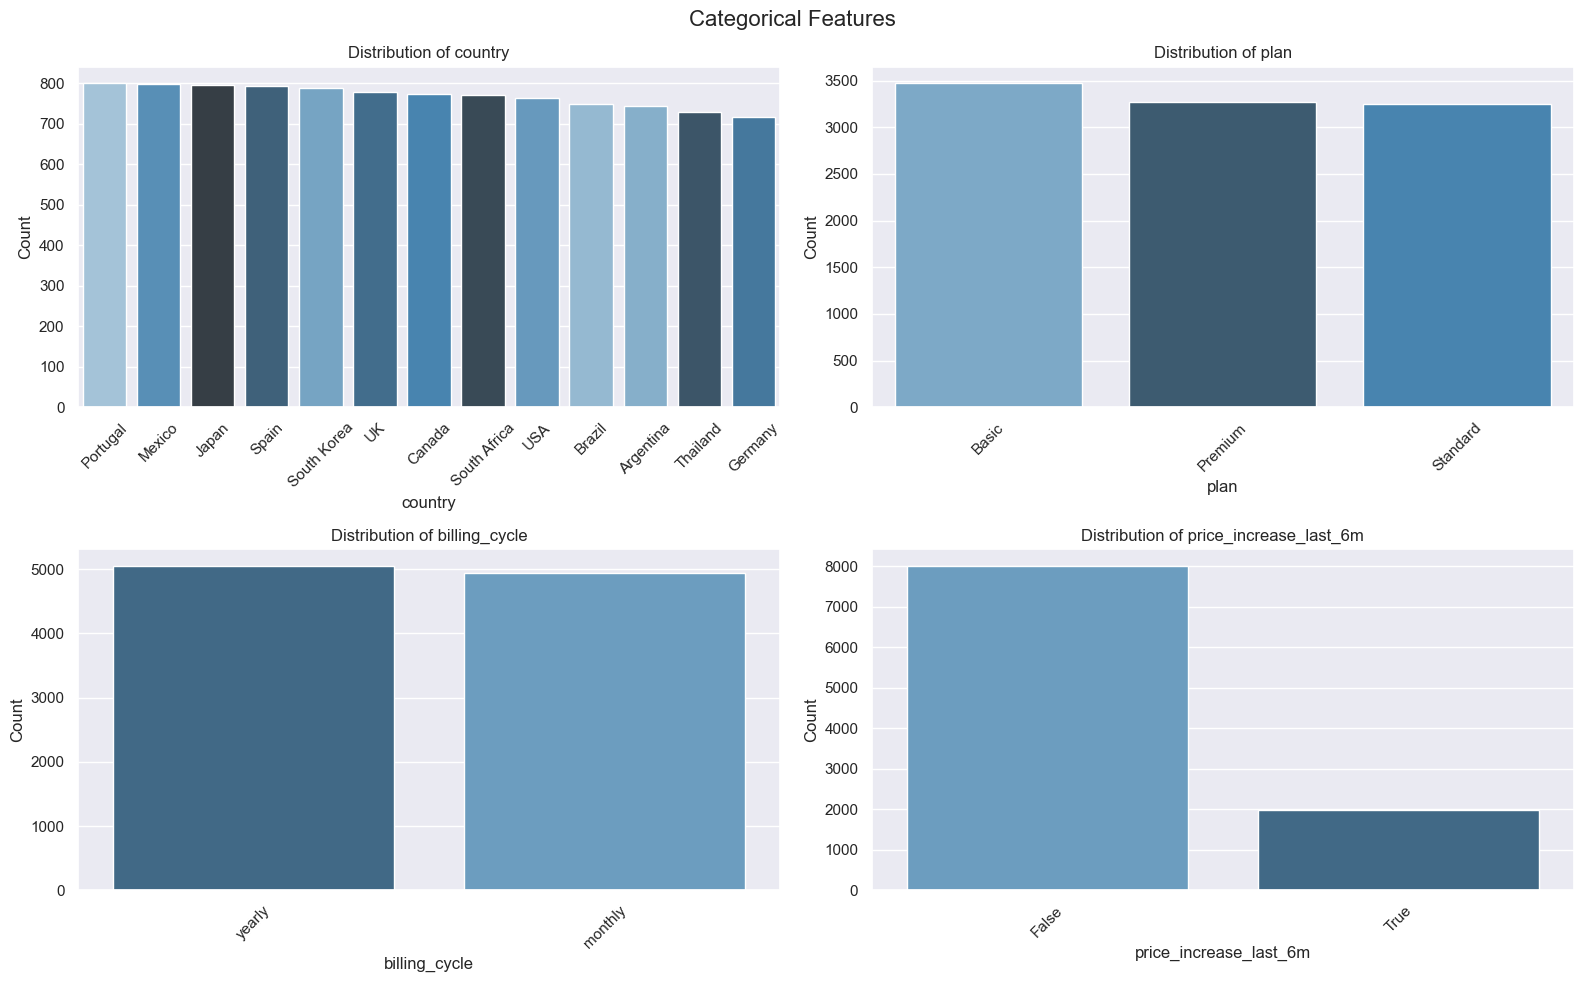

In [44]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], order=order, hue=col, palette="Blues_d", legend=False)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Categorical Features", fontsize=16)
plt.tight_layout()
plt.savefig("graphs/single_variable_categorical.png", dpi=150, bbox_inches="tight")
plt.show()

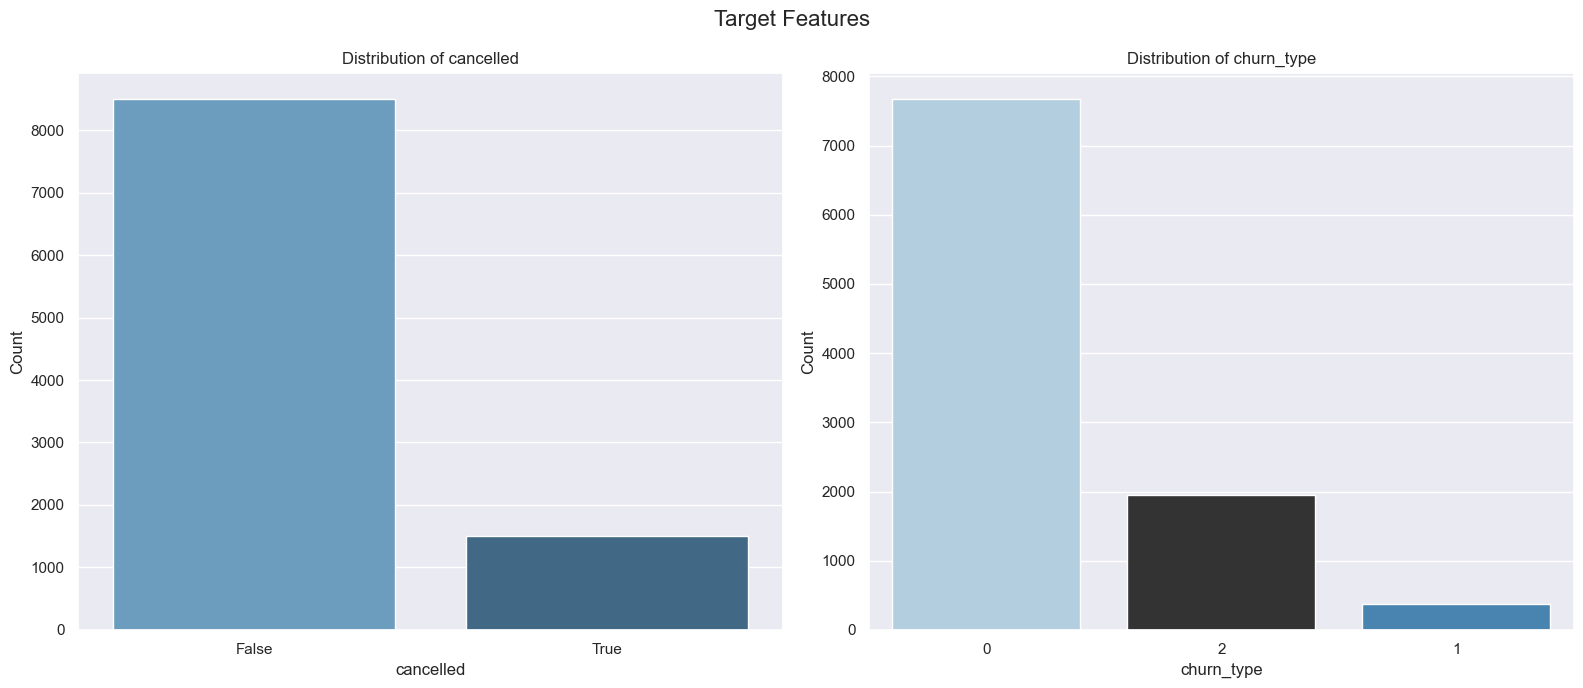

In [45]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(TARGET_COLS):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], order=order, hue=col, palette="Blues_d", legend=False)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.suptitle("Target Features", fontsize=16)
plt.tight_layout()
plt.savefig("graphs/target-features.png", dpi=150, bbox_inches="tight")
plt.show()

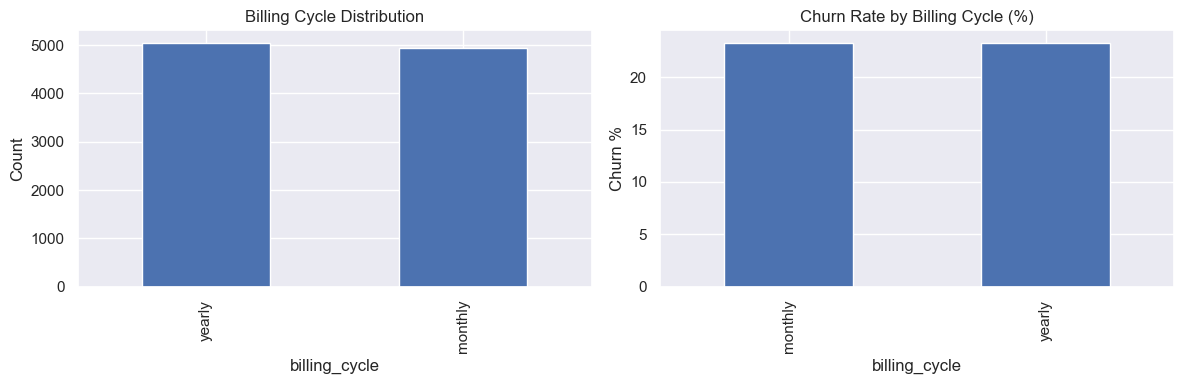

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Billing cycle distribution
df["billing_cycle"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Billing Cycle Distribution")
axes[0].set_ylabel("Count")

# Churn rate by billing cycle (churn_type != 0 means churned)
churn_rate = df.groupby("billing_cycle")["churn_type"].apply(
    lambda x: (x != 0).mean() * 100
).round(1)

churn_rate.plot(kind="bar", ax=axes[1])
axes[1].set_title("Churn Rate by Billing Cycle (%)")
axes[1].set_ylabel("Churn %")

plt.savefig("graphs/monthly_vs_yearly_billing.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [47]:
# Cancellation rate overall
cancelled = df["cancelled"].value_counts()
cancelled_pct = df["cancelled"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%"
print(pd.DataFrame({"count": cancelled, "%": cancelled_pct}))

           count      %
cancelled              
False       8496  85.0%
True        1504  15.0%


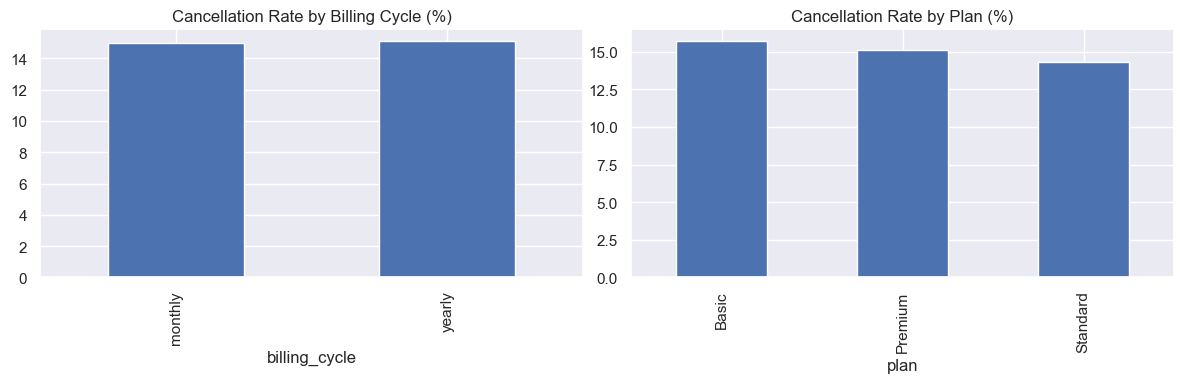

In [48]:
# Cancellation rate by billing cycle and plan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby("billing_cycle")["cancelled"].mean().mul(100).round(1).plot(kind="bar", ax=axes[0])
axes[0].set_title("Cancellation Rate by Billing Cycle (%)")

df.groupby("plan")["cancelled"].mean().mul(100).round(1).plot(kind="bar", ax=axes[1])
axes[1].set_title("Cancellation Rate by Plan (%)")

plt.savefig("graphs/cancellation_rate.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

C:\Users\laura\AppData\Local\Temp\ipykernel_12932\3376845859.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby(pd.cut(df["days_until_renewal"], bins=bins, labels=labels))["churn_type"].apply(


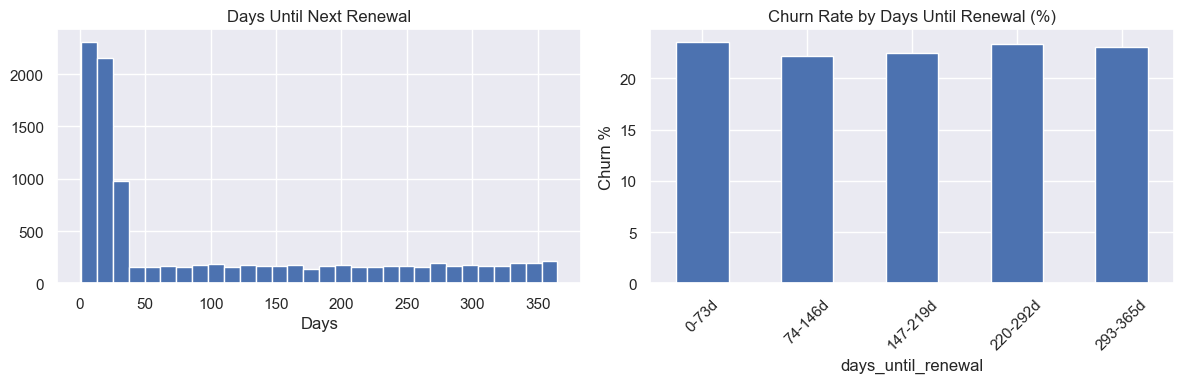

In [49]:
reference_date = pd.Timestamp(datetime.now().date())
df["days_until_renewal"] = (df["next_renewal_date"] - reference_date).dt.days

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of days until next renewal
df["days_until_renewal"].hist(bins=30, ax=axes[0])
axes[0].set_title("Days Until Next Renewal")
axes[0].set_xlabel("Days")

# Churn rate by proximity to renewal date
bins = [0, 73, 146, 219, 292, 365]
labels = ["0-73d", "74-146d", "147-219d", "220-292d", "293-365d"]

churn_rate = df.groupby(pd.cut(df["days_until_renewal"], bins=bins, labels=labels))["churn_type"].apply(
    lambda x: (x != 0).mean() * 100
).round(1)

churn_rate.plot(kind="bar", ax=axes[1])
axes[1].set_title("Churn Rate by Days Until Renewal (%)")
axes[1].set_ylabel("Churn %")
axes[1].tick_params(axis='x', rotation=45)

plt.savefig("graphs/renewal_dates.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [50]:
df.drop(columns=["days_until_renewal"], inplace=True) 

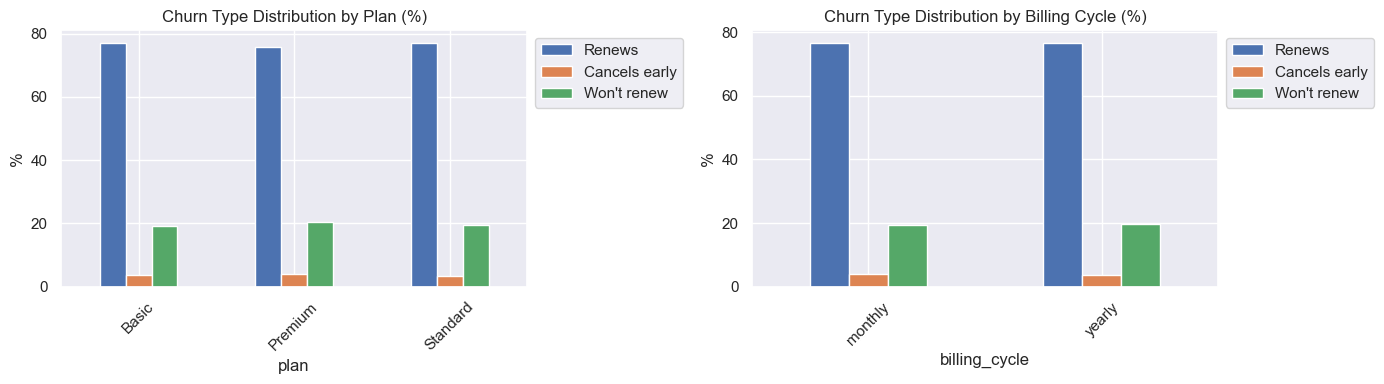

In [51]:
# Churn type distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby("plan")["churn_type"].value_counts(normalize=True).mul(100).unstack().plot(kind="bar", ax=axes[0])
axes[0].set_title("Churn Type Distribution by Plan (%)")
axes[0].set_ylabel("%")
axes[0].legend(["Renews", "Cancels early", "Won't renew"], 
               loc="upper left", bbox_to_anchor=(1, 1))
axes[0].tick_params(axis='x', rotation=45)

df.groupby("billing_cycle")["churn_type"].value_counts(normalize=True).mul(100).unstack().plot(kind="bar", ax=axes[1])
axes[1].set_title("Churn Type Distribution by Billing Cycle (%)")
axes[1].set_ylabel("%")
axes[1].legend(["Renews", "Cancels early", "Won't renew"], 
               loc="upper left", bbox_to_anchor=(1, 1))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Multi-Variable Analysis

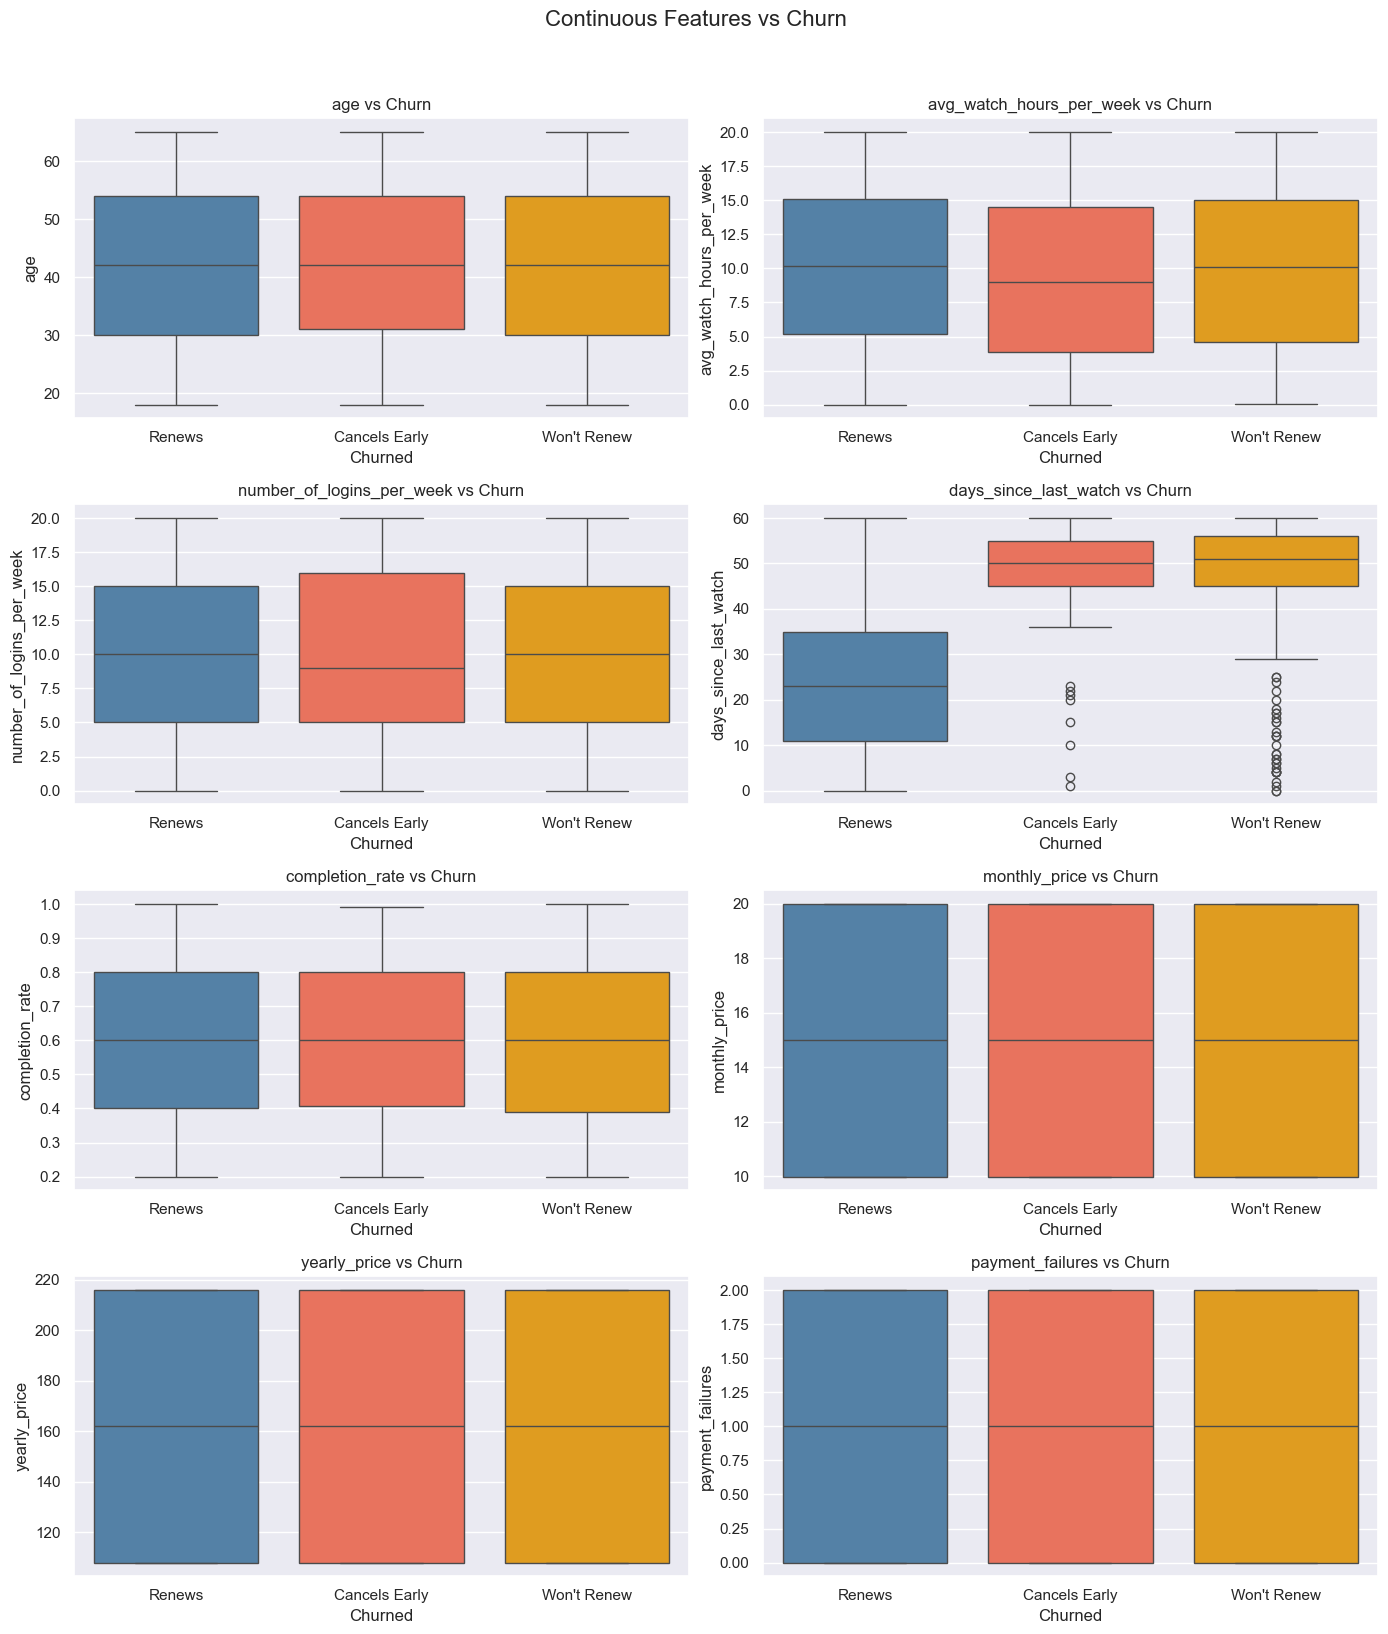

In [52]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

#temporary columns, made only for the visualization
df["churn_label"] = df["churn_type"].map({0: "Renews", 1: "Cancels Early", 2: "Won't Renew"})

for i, col in enumerate(CONTINUOUS_COLS):
    sns.boxplot(
        data=df, x="churn_label", y=col, ax=axes[i],
        hue="churn_label", 
        palette={"Renews": "steelblue", "Cancels Early": "tomato", "Won't Renew": "orange"},
        order=["Renews", "Cancels Early", "Won't Renew"], legend=False
    )
    axes[i].set_title(f"{col} vs Churn")
    axes[i].set_xlabel("Churned")
    axes[i].set_ylabel(col)
    
plt.suptitle("Continuous Features vs Churn", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("graphs/multi_variable_continuous.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
df.drop(columns=["churn_label"], inplace=True) 

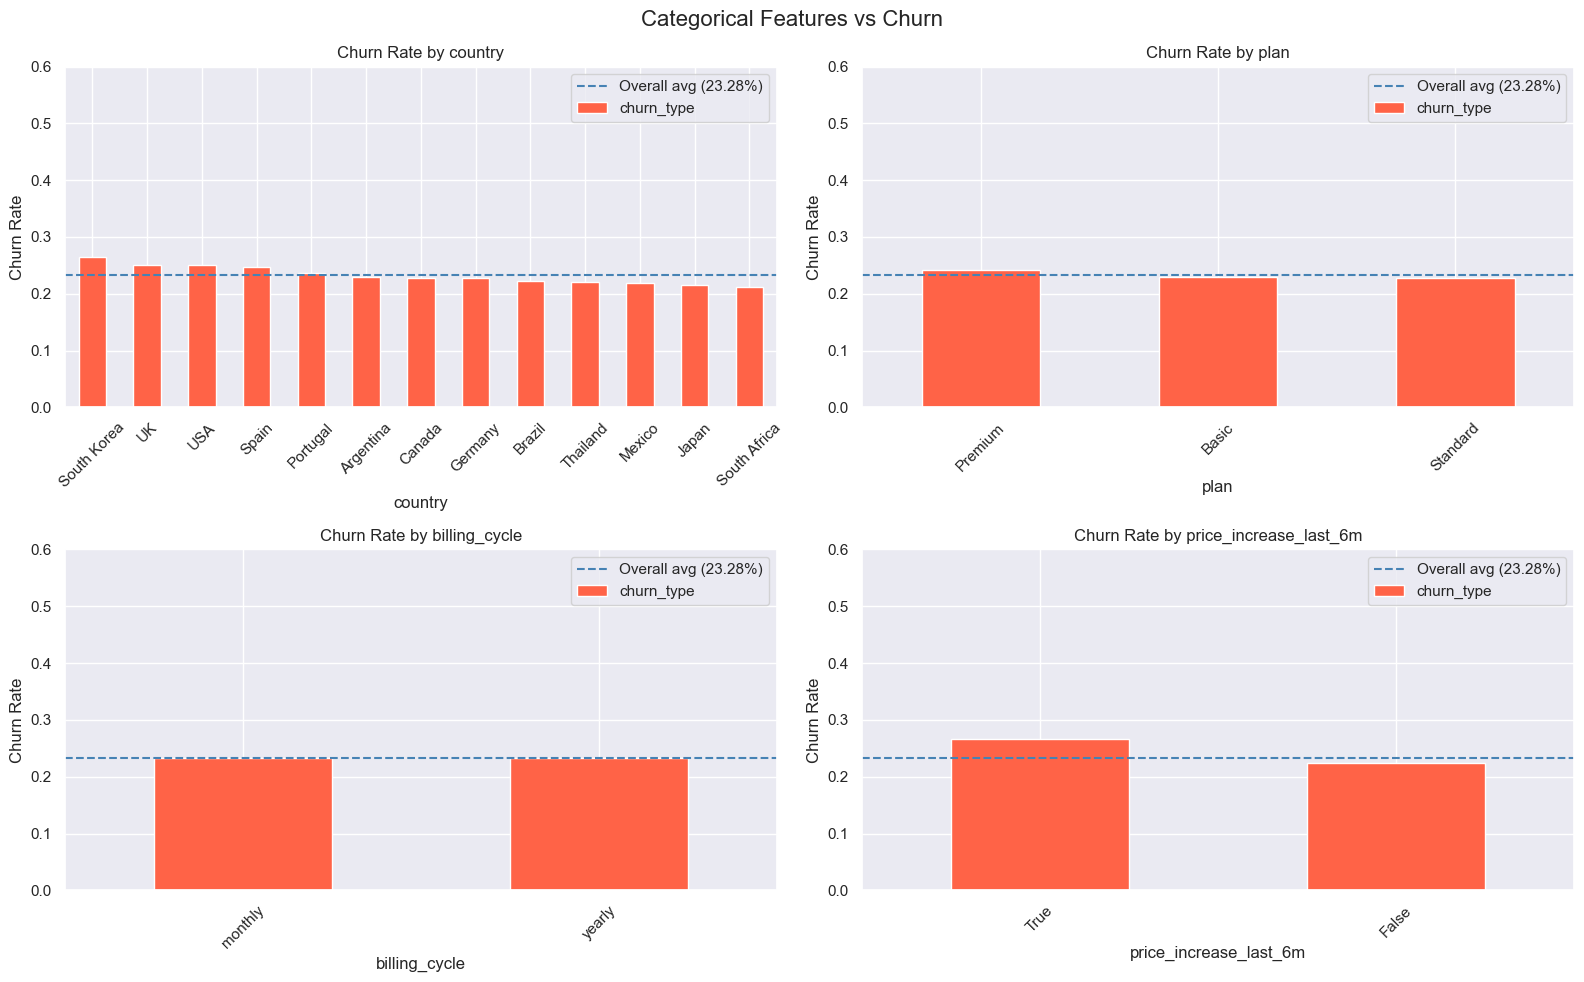

In [54]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

# churn rate = % of users with churn_type != 0
overall_churn_rate = (df["churn_type"] != 0).mean()

for i, col in enumerate(CATEGORICAL_COLS):
    churn_rate = df.groupby(col)["churn_type"].apply(
        lambda x: (x != 0).mean()
    ).sort_values(ascending=False)
    
    churn_rate.plot(kind="bar", ax=axes[i], color="tomato", edgecolor="white")
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_ylim(0, 0.6)
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].axhline(
        overall_churn_rate, color="steelblue",
        linestyle="--", linewidth=1.5, label=f"Overall avg ({overall_churn_rate:.2%})"
    )
    axes[i].legend()

plt.suptitle("Categorical Features vs Churn", fontsize=16)
plt.tight_layout()
plt.savefig("graphs/multi_variable_categorical.png", dpi=150, bbox_inches="tight")
plt.show()

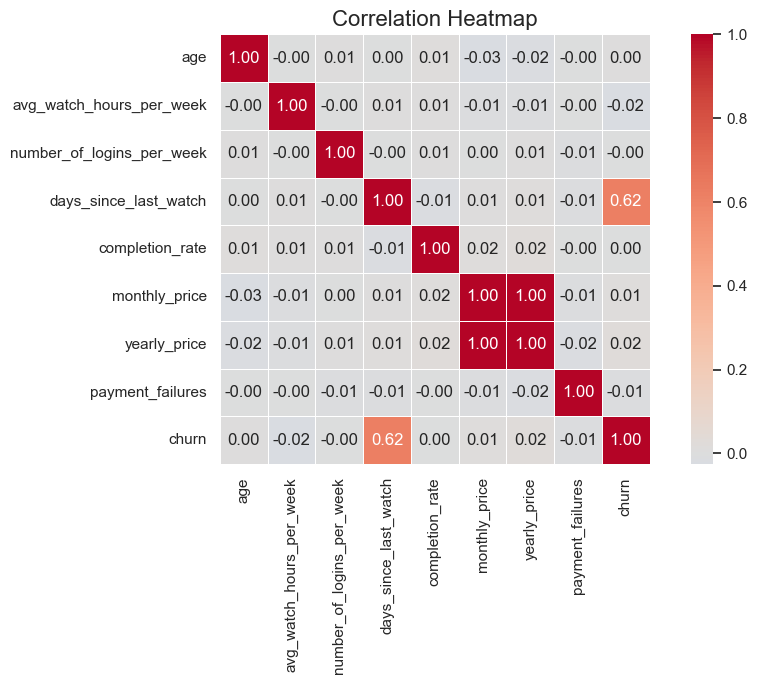

In [55]:
fig, ax = plt.subplots(figsize=(10, 7))

numeric_df = df[CONTINUOUS_COLS].copy()
numeric_df["churn"] = (df["churn_type"] != 0).astype(int)

corr = numeric_df.corr()

sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax, square=True
)

ax.set_title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.savefig("graphs/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
churn_corr = corr["churn"].drop("churn").sort_values(key=abs, ascending=False)
print("\nFeature correlation with churn (sorted by strength):")
print(churn_corr.to_string())


Feature correlation with churn (sorted by strength):
days_since_last_watch        0.622531
avg_watch_hours_per_week    -0.023911
yearly_price                 0.021733
monthly_price                0.012682
payment_failures            -0.007535
age                          0.003604
number_of_logins_per_week   -0.002706
completion_rate              0.002096


In [57]:
df.to_parquet("data/clean_data.parquet", index=False)